In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc

# pseudo dynamics input

from where we can extract the cellbarcodes and their correponding cell states

In [2]:
input = pd.read_csv("../../data/meahr/pdny_input/pseudodynamics_input_maehr17_dpt_branching_TCandNK.csv")

input['cell'] = input['cell'].apply(lambda x: x.replace(".e", ".E").replace('5whole', '5_Whole'))
input['cell']  = input['cell'].apply(lambda x : x.replace("P0_RightLobe", "P0_WholeThy_rep2"))
input['cell']  = input['cell'].apply(lambda x : x.replace("P0_LeftLobe", "P0_WholeThy_rep1"))

input['batch'] = input['batch'].apply(lambda x: x.replace("e1", "E1").replace('5whole', '5_Whole'))
input['barcodes'] = input['cell'].apply(lambda x: x.split(".")[0])
input['batch_to_match'] = input['cell'].apply(lambda x: x.split(".")[1])

# experimetns with P0 
# P0cells = input[input['batch'].apply(lambda x: x.startswith('P0'))]

In [3]:
input.shape

(10872, 13)

# individual count

In [4]:
data_dir = "../../data/meahr/count_and_tcr"

In [5]:
dge_tables = [file for file in os.listdir(data_dir) if 'dge.txt' in file]

In [6]:
len(dge_tables) # 54 embryos

54

In [7]:
import re

In [8]:
embryo_idx_regexp = re.compile(r"GSM\d{7,9}_[E|P](\d{1,2})(_\d)?_(\w*_\d).dge.txt")

dge = []
for i,table in enumerate(dge_tables):
    if embryo_idx_regexp.match(table):
        dge.append(table)

len(dge)

19

In [9]:
embryo_idx_regexp = re.compile(r"GSM\d{7,9}_[E|P](\d{1,2})(_\d)?_(\w*_\d)_tcr.dge.txt")

tcr_dge = []
for i,table in enumerate(dge_tables):
    if embryo_idx_regexp.match(table):
        tcr_dge.append(table)

len(tcr_dge)


19

In [10]:
# the others 
others = [table for table in dge_tables if table not in dge and table not in tcr_dge]
len(others)

16

In [11]:
others

['GSM2883209_FTOC_RA_2_tcr.dge.txt',
 'GSM2883206_FTOC_PBSDMSO_2_tcr.dge.txt',
 'GSM2883208_FTOC_RA_1_tcr.dge.txt',
 'GSM2883205_FTOC_PBSDMSO_1_tcr.dge.txt',
 'GSM2883205_FTOC_PBSDMSO_1.dge.txt',
 'GSM2883204_Rag1KO_wholeThy_2.dge.txt',
 'GSM2883209_FTOC_RA_2.dge.txt',
 'GSM2883203_Rag1KO_wholeThy_1_tcr.dge.txt',
 'GSM2883210_FTOC_RA_3.dge.txt',
 'GSM2883204_Rag1KO_wholeThy_2_tcr.dge.txt',
 'GSM2883206_FTOC_PBSDMSO_2.dge.txt',
 'GSM2883210_FTOC_RA_3_tcr.dge.txt',
 'GSM2883203_Rag1KO_wholeThy_1.dge.txt',
 'GSM2883208_FTOC_RA_1.dge.txt',
 'GSM2883207_FTOC_PBSDMSO_3.dge.txt',
 'GSM2883207_FTOC_PBSDMSO_3_tcr.dge.txt']

# read the normal whole thymus 

In [12]:
dge_dict = {}

# to extract
regexp = re.compile(r"GSM\d{7,9}_([E|P]\d{1,2}(_\d)?)_(WholeThy.*)_(\d).dge.txt")

for file in dge:

    stage, _,  section, rep = regexp.match(file.replace("whole", "Whole")).groups()
    
    # namming systam
    batch =  f"{stage}_{section}_rep{rep}"

    dge_csv = pd.read_table(os.path.join(data_dir,file)).set_index("GENE").T
    dge_dict[batch] = dge_csv


# check total num of cells
np.sum([df.shape[0] for df in dge_dict.values()])

15429

In [13]:
all_cbs= np.concatenate([df.index for df in dge_dict.values()])
len(np.unique(all_cbs))

15419

In [14]:
import anndata as ad

In [15]:
adatas = []
for batch, df in dge_dict.items():

    barcodes = list(df.index)
    cbs = [o+f'.{batch}' for o in barcodes]
    obs = pd.DataFrame(
        {'cb':cbs, 'barcodes':barcodes, "batch":[batch]*df.shape[0]}
    ).set_index("cb")

    
    gene = list(df.columns)
    var = pd.DataFrame(
        {'Gene':gene}
    ).set_index("Gene")

    adatas.append( ad.AnnData(X = df.values, obs=obs, var=var) )


In [16]:
adata = ad.concat(adatas)


In [17]:
adata

AnnData object with n_obs × n_vars = 15429 × 11081
    obs: 'barcodes', 'batch'

In [18]:
adata.obs_names

Index(['GGCATCGGTTAT.E17_5_WholeThy_rep2', 'TTTACTTTAGAG.E17_5_WholeThy_rep2',
       'GTGCCGGGACAT.E17_5_WholeThy_rep2', 'ATTGTCTATATA.E17_5_WholeThy_rep2',
       'ACTCAAAAATTC.E17_5_WholeThy_rep2', 'ATACACGGCCGN.E17_5_WholeThy_rep2',
       'TAAAAAACAGTT.E17_5_WholeThy_rep2', 'ATGACTCTTTCT.E17_5_WholeThy_rep2',
       'TATTGATCAATG.E17_5_WholeThy_rep2', 'TGAGACGATGAG.E17_5_WholeThy_rep2',
       ...
       'TCCGGTCAGGGA.P0_WholeThy_rep1', 'GGGCCCCGAGAC.P0_WholeThy_rep1',
       'GCGAATCTGTTA.P0_WholeThy_rep1', 'ACTTCATGTCAN.P0_WholeThy_rep1',
       'AAAGTCTGAAAT.P0_WholeThy_rep1', 'TGGGTGATGTGT.P0_WholeThy_rep1',
       'GCCCCCGGTTGC.P0_WholeThy_rep1', 'CGCCTATGGGCT.P0_WholeThy_rep1',
       'GTCACAGCTGAN.P0_WholeThy_rep1', 'TCTGAACACCAC.P0_WholeThy_rep1'],
      dtype='object', name='cb', length=15429)

then we save the data

In [197]:
adata.write_h5ad("../../data/meahr/raw_count_merged.h5ad")

# reanalyse the raw one

In [5]:
adata  = sc.read_h5ad("../../data/meahr/raw_count_merged.h5ad")

In [7]:
adata.raw = sc.pp.log1p(adata, copy=True)
sc.pp.recipe_weinreb17(adata, log=False,  random_state=0) # Do log-transform.
sc.pp.neighbors(adata, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)

In [8]:
sc.pp.neighbors(adata, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)
sc.tl.tsne(adata)

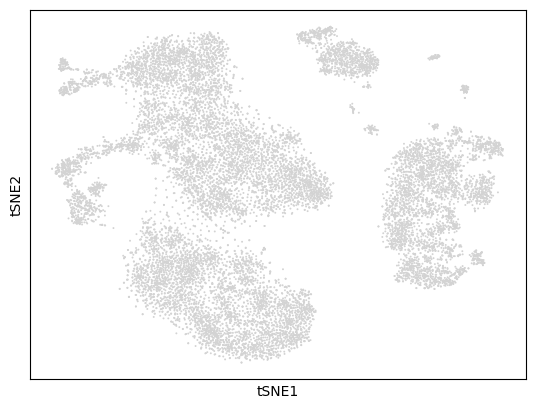

In [9]:
sc.pl.tsne(adata)

In [10]:
merged = adata.obs.merge(input, left_on=['barcodes'], right_on=['barcodes'])

In [12]:
merged['obs_names'] = merged.apply(lambda x : f"{x['barcodes']}.{x['batch_x']}", axis=1)
merged_adata = adata[merged['obs_names'].values].copy()

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


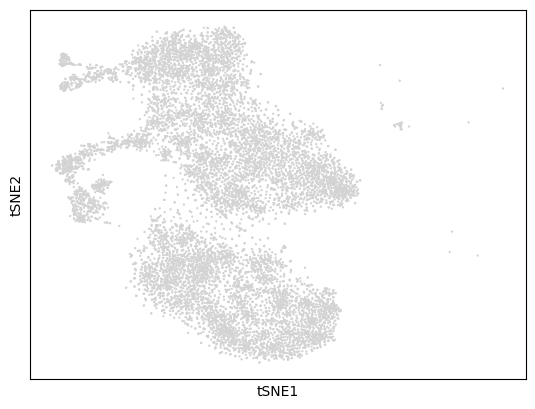

In [14]:
sc.pl.tsne(merged_adata)

In [ ]:
sc.pl.tsne(adata)

# match meahr with pydn input

In [168]:
obs = adata.obs.copy()

In [194]:
venus = ['E12_5_WholeThy_venus_rep3', 'E12_5_WholeThy_venus_rep2', 'E12_5_WholeThy_venus_rep1']
input.query("`batch` in @venus")

,pseudodynamics_branching_region,pseudodynamics_branch_class,dpt_adjusted_groups,time,batch,pseudotime,cell,dc1,dc2,dc3,dc4,barcodes
0,branching,NK,intermediate,12.5,E12_5_WholeThy_venus_rep3,0.203278,TCGCGGACCCAC.E12_5_WholeThy_venus_rep3,0.001360,0.000922,-0.001408,0.002208,TCGCGGACCCAC
1,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep3,0.147283,CCGATACCTGGG.E12_5_WholeThy_venus_rep3,0.006107,-0.007332,-0.003920,0.003467,CCGATACCTGGG
2,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep3,0.177263,TAAAACAGACGG.E12_5_WholeThy_venus_rep3,0.005499,-0.002865,-0.002496,0.006173,TAAAACAGACGG
3,nonbranching,progenitor,progenitor,12.5,E12_5_WholeThy_venus_rep3,0.035914,GATTAGAGCCGN.E12_5_WholeThy_venus_rep3,0.010215,-0.012994,-0.016835,-0.010867,GATTAGAGCCGN
4,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep3,0.046453,TTCACGCTACGA.E12_5_WholeThy_venus_rep3,0.010201,-0.013046,-0.016699,-0.011438,TTCACGCTACGA
...,...,...,...,...,...,...,...,...,...,...,...,...
2202,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep2,0.062205,CCAGGAAGATAA.E12_5_WholeThy_venus_rep2,0.008673,-0.011471,-0.012842,-0.008060,CCAGGAAGATAA
2203,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep2,0.169234,GCTTGGATGGCA.E12_5_WholeThy_venus_rep2,0.005598,-0.003512,-0.004556,0.000473,GCTTGGATGGCA
2204,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep2,0.111979,TTAAGCGTTAAA.E12_5_WholeThy_venus_rep2,0.006733,-0.009411,-0.007232,-0.002912,TTAAGCGTTAAA
2205,branching,TC,intermediate,12.5,E12_5_WholeThy_venus_rep2,0.057336,CTACAAGACCAA.E12_5_WholeThy_venus_rep2,0.009074,-0.011343,-0.013265,-0.008397,CTACAAGACCAA


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

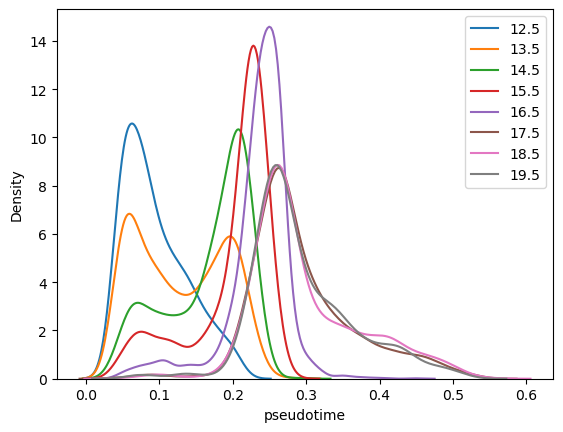

In [42]:
for t in sorted(input.time.unique()):
    sns.kdeplot(data=input.query("`pseudodynamics_branch_class` == 'TC' & `time` == @t"), x='pseudotime', label=t)
    plt.legend()

In [188]:
input['barcodes']

0        TCGCGGACCCAC
1        CCGATACCTGGG
2        TAAAACAGACGG
3        GATTAGAGCCGN
4        TTCACGCTACGA
             ...     
10867    CATACGCCTAGN
10868    AGAAGAGTCGCN
10869    CAAACCCGTCAN
10870    CCTTTCCGCGAC
10871    TTAACTACGACA
Name: barcodes, Length: 10872, dtype: object

In [189]:
E12obs  = obs[obs.batch.apply(lambda x : x.startswith("E12_5"))]

In [25]:
adata.obs.batch.value_counts().shape

(19,)

In [24]:
input.batch_to_match.value_counts().shape

(19,)

In [31]:
adata.obs

,barcodes,batch
cb,,
GGCATCGGTTAT.E17_5_WholeThy_rep2,GGCATCGGTTAT,E17_5_WholeThy_rep2
TTTACTTTAGAG.E17_5_WholeThy_rep2,TTTACTTTAGAG,E17_5_WholeThy_rep2
GTGCCGGGACAT.E17_5_WholeThy_rep2,GTGCCGGGACAT,E17_5_WholeThy_rep2
ATTGTCTATATA.E17_5_WholeThy_rep2,ATTGTCTATATA,E17_5_WholeThy_rep2
ACTCAAAAATTC.E17_5_WholeThy_rep2,ACTCAAAAATTC,E17_5_WholeThy_rep2
...,...,...
TGGGTGATGTGT.P0_WholeThy_rep1,TGGGTGATGTGT,P0_WholeThy_rep1
GCCCCCGGTTGC.P0_WholeThy_rep1,GCCCCCGGTTGC,P0_WholeThy_rep1
CGCCTATGGGCT.P0_WholeThy_rep1,CGCCTATGGGCT,P0_WholeThy_rep1


In [32]:
regexp = re.compile(r"([E|P]\d{1,2}(_\d)?)_(WholeThy.*).*")

In [33]:
def time_extract(x):

 regexp.match(x).group(1)

In [35]:
adata.obs.batch.apply(time_extract).value_counts()

batch
E13_5    3769
E16_5    2831
E17_5    2036
E12_5    1747
E14_5    1654
E15_5    1506
P0        973
E18_5     913
Name: count, dtype: int64

In [45]:
adata.obs_names

Index(['GGCATCGGTTAT.E17_5_WholeThy_rep2', 'TTTACTTTAGAG.E17_5_WholeThy_rep2',
       'GTGCCGGGACAT.E17_5_WholeThy_rep2', 'ATTGTCTATATA.E17_5_WholeThy_rep2',
       'ACTCAAAAATTC.E17_5_WholeThy_rep2', 'ATACACGGCCGN.E17_5_WholeThy_rep2',
       'TAAAAAACAGTT.E17_5_WholeThy_rep2', 'ATGACTCTTTCT.E17_5_WholeThy_rep2',
       'TATTGATCAATG.E17_5_WholeThy_rep2', 'TGAGACGATGAG.E17_5_WholeThy_rep2',
       ...
       'TCCGGTCAGGGA.P0_WholeThy_rep1', 'GGGCCCCGAGAC.P0_WholeThy_rep1',
       'GCGAATCTGTTA.P0_WholeThy_rep1', 'ACTTCATGTCAN.P0_WholeThy_rep1',
       'AAAGTCTGAAAT.P0_WholeThy_rep1', 'TGGGTGATGTGT.P0_WholeThy_rep1',
       'GCCCCCGGTTGC.P0_WholeThy_rep1', 'CGCCTATGGGCT.P0_WholeThy_rep1',
       'GTCACAGCTGAN.P0_WholeThy_rep1', 'TCTGAACACCAC.P0_WholeThy_rep1'],
      dtype='object', name='cb', length=15429)

In [26]:
merged = adata.obs.merge(input, left_on=['barcodes'], right_on=['barcodes'])

In [43]:
merged[merged['batch_x'].values != merged['batch_to_match'].values][['batch_x', 'batch_to_match']]

,batch_x,batch_to_match
166,E17_5_WholeThy_rep2,E17_5_WholeThy_rep1
169,E17_5_WholeThy_rep1,E17_5_WholeThy_rep2
353,E17_5_WholeThy_rep2,E18_5_WholeThy_rep1
354,E18_5_WholeThy_rep1,E17_5_WholeThy_rep2
570,E17_5_WholeThy_rep2,E15_5_WholeThy_Rep2
...,...,...
10461,E14_5_WholeThy_rep1,E14_5_WholeThy_rep2
10462,E14_5_WholeThy_rep1,E14_5_WholeThy_rep2
10463,E14_5_WholeThy_rep1,E14_5_WholeThy_rep2
10464,E14_5_WholeThy_rep1,E14_5_WholeThy_rep2


In [57]:
merged['Time_x'] = merged['batch_x'].str.extract('([E|P]\d{1,2}(_\d)?)')[0].values
merged['Time_y'] = merged['batch_to_match'].str.extract('([E|P]\d{1,2}(_\d)?)')[0].values

In [59]:
np.mean(merged['Time_x'] == merged['Time_y'])

0.9985307621671258

# save the adata as David;s barcode

In [55]:
merged['obs_names'] = merged.apply(lambda x : f"{x['barcodes']}.{x['batch_x']}", axis=1)

merged_adata = adata[merged['obs_names'].values].copy()
merged_adata.obs = merged.set_index("obs_names")
merged_adata.obsm['X_dc'] = merged_adata.obs[['dc1','dc2','dc3','dc4']].values

merged_adata.write_h5ad("/ssd/users/Wergillius/Project/PINN_dynamics/data/meahr/David_cb.h5ad")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
